**Задание 1. Классификация ирисов**

Обучите классификатор ирисов, используя изученные на этом занятии модели. Оцените точность обученных моделей. Попробуйте достигнуть 85-90% точности.

*Рекомендации по выполнению задания:*

- данные для обучения можно получить с помощью библиотеки sklearn ([ссылка на документацию](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset));
- разделение данных на тренировочную и тестовую выборки можно осуществить с помощью функции `train_test_split` из модуля `sklearn.model_selection`;
- чтобы оценить влияние конкретного гиперпараметра на качество модели, меняйте значение этого гиперпараметра с определенным шагом, предварительно зафиксировав значения других гиперпараметров.


### Загружаем различные библиотеки




In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

In [ ]:
# использует только 2 признака для обучения!
# X, y - набор данных для отображения, X_train, y_train - данные для обучения
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train)

    plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf)
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title(title)

### Загрузка "Ириса Фишера"

In [6]:
X, y = load_iris(return_X_y=True, as_frame=True)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

здесь можно было бы также применить стандартизацию (масштабирование)

### Рассмотрим алгоритм KNN-классификатора

Точность у обученной модели 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



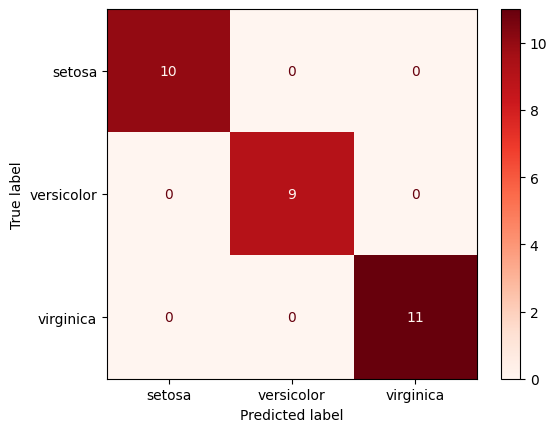

In [ ]:
model_KNN_class = KNeighborsClassifier(n_neighbors=3)
model_KNN_class.fit(X_train, y_train)
pred_KNN = model_KNN_class.predict(X_test)

KNN_accuracy = accuracy_score(y_test, pred_KNN)
print(f"Точность у обученной модели {KNN_accuracy}")
print(classification_report(y_test, pred_KNN))

cm = confusion_matrix(y_test, pred_KNN, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)

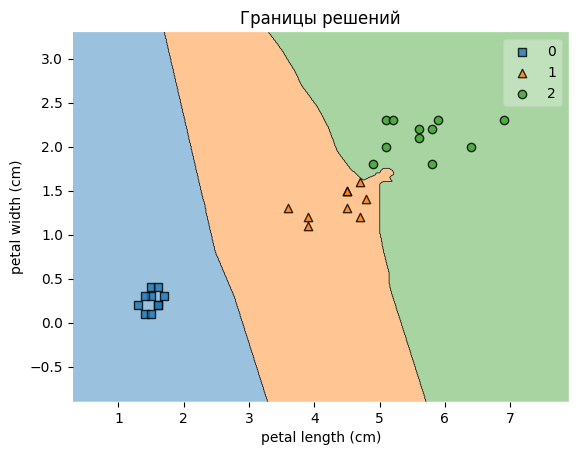

In [ ]:
#Границы решений - petal/лепесток - sepals/чашелистик
feature_indexes = [2, 3]
title1 = 'Границы решений'
decision_boundary_plot(X_test, y_test, X_train.values, y_train.values, model_KNN_class, feature_indexes, title1)


### Рассмотрим точность алгоритма KNN с различными знаениями гиперпараметра k-соседей

Точность у обученной модели 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



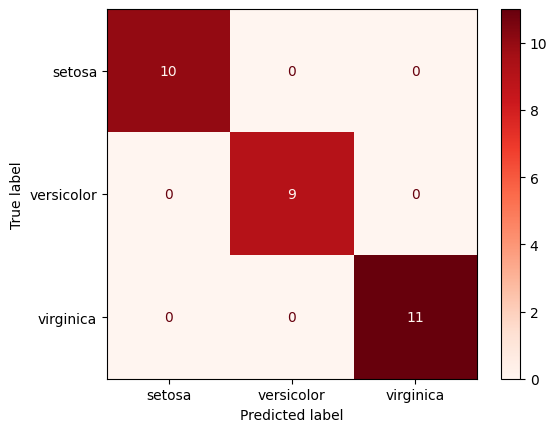

In [ ]:
model_KNN_class_2 = KNeighborsClassifier(n_neighbors=9)
model_KNN_class_2.fit(X_train, y_train)
pred_KNN_2 = model_KNN_class_2.predict(X_test)
KNN_accuracy_2 = accuracy_score(y_test, pred_KNN_2)
print(f"Точность у обученной модели {KNN_accuracy_2}")

print(classification_report(y_test, pred_KNN))

cm = confusion_matrix(y_test, pred_KNN, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)


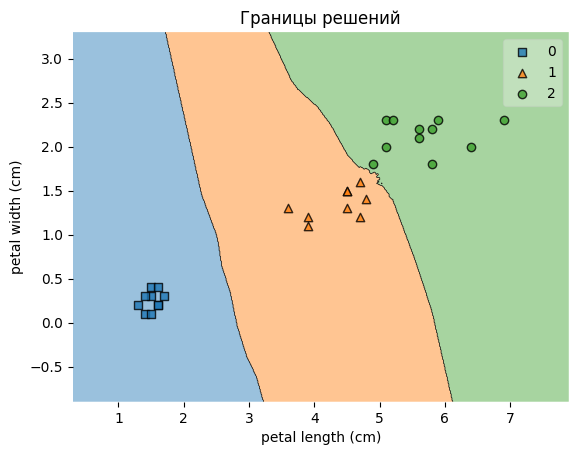

In [ ]:
#Границы решений - petal/лепесток - sepals/чашелистик
feature_indexes = [2, 3]
title1 = 'Границы решений'
decision_boundary_plot(X_test, y_test, X_train.values, y_train.values, model_KNN_class_2, feature_indexes, title1)


Точность у обученной модели 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



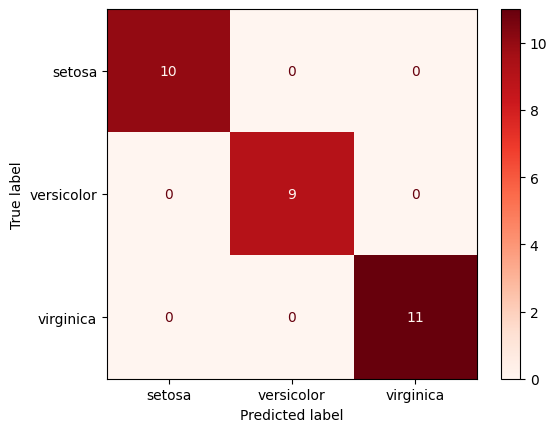

In [ ]:
model_KNN_class_3 = KNeighborsClassifier(n_neighbors=27)
model_KNN_class_3.fit(X_train, y_train)
pred_KNN_3 = model_KNN_class_3.predict(X_test)
KNN_accuracy_3 = accuracy_score(y_test, pred_KNN_3)
print(f"Точность у обученной модели {KNN_accuracy}")

print(classification_report(y_test, pred_KNN))

cm = confusion_matrix(y_test, pred_KNN, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)

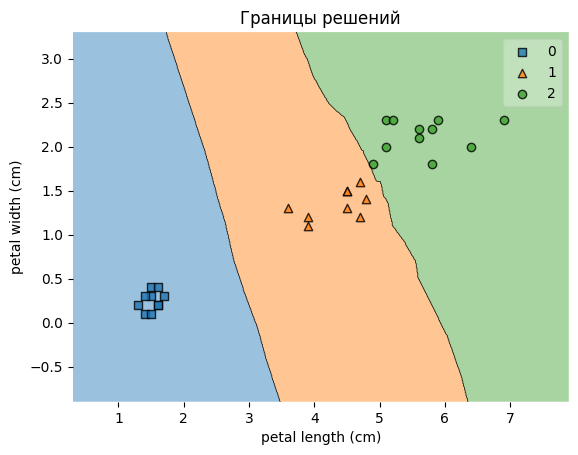

In [ ]:
#Границы решений - petal/лепесток - sepals/чашелистик
feature_indexes = [2, 3]
title1 = 'Границы решений'
decision_boundary_plot(X_test, y_test, X_train.values, y_train.values, model_KNN_class_3, feature_indexes, title1)


Точность у обученной модели 0.9473684210526315 при k=3 - переобучение - учитывает маленький диапазон соседей
Точность у обученной модели 0.9736842105263158 при k=9 - норм обучение - учитывает достаточный диапазон соседей
Точность у обученной модели 0.9473684210526315 при k=27 - недообучение - учитывает очень общирный диапазон соседей

### Рассмотрим алгоритм логиситческой регрессии

Применим масштабирование - метод StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Точность с примененной стандартизацией (масштабируем): 0.933 (93.3%)


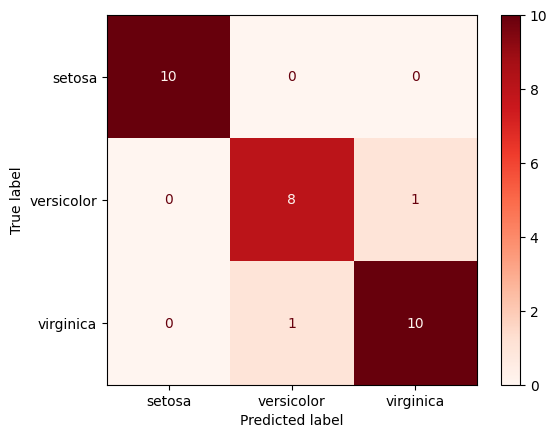

In [ ]:
model_Log_Reg = LogisticRegression(C=0.001, max_iter=1000)
model_Log_Reg.fit(X_train_scaled, y_train)
pred_Log_Reg = model_Log_Reg.predict(X_test_scaled)
accuracy_poly = accuracy_score(y_test, pred_Log_Reg)
print(f"Точность с примененной стандартизацией (масштабируем): {accuracy_poly:.3f} ({accuracy_poly*100:.1f}%)")

cm = confusion_matrix(y_test, pred_Log_Reg, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)



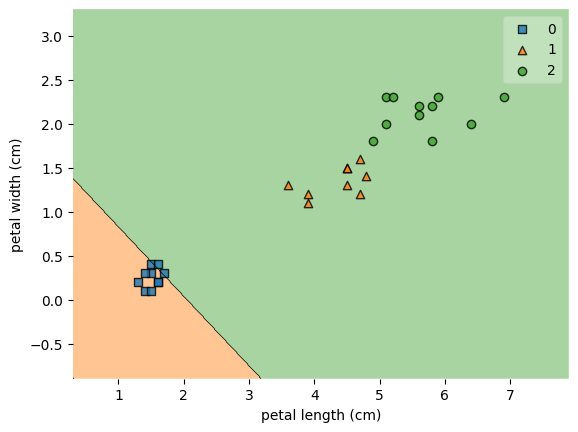

In [ ]:
decision_boundary_plot(X_test, y_test, X_train_scaled, y_train, model_Log_Reg, feature_indexes=[2,3])

Точность с примененной стандартизацией (масштабируем): 1.000 (100.0%)


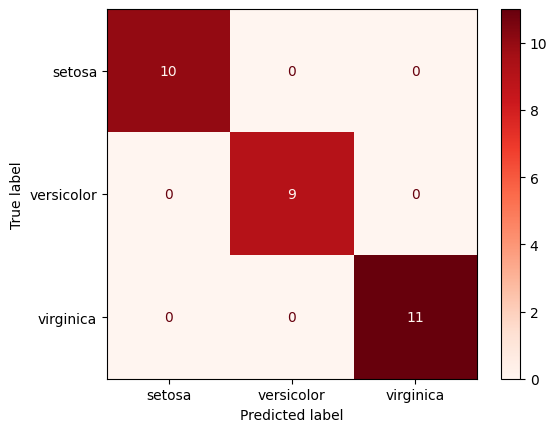

In [ ]:
model_Log_Reg_2 = LogisticRegression(C=1, max_iter=1000)
model_Log_Reg_2.fit(X_train_scaled, y_train)
pred_Log_Reg_2 = model_Log_Reg_2.predict(X_test_scaled)
accuracy_poly = accuracy_score(y_test, pred_Log_Reg_2)
print(f"Точность с примененной стандартизацией (масштабируем): {accuracy_poly:.3f} ({accuracy_poly*100:.1f}%)")

cm = confusion_matrix(y_test, pred_Log_Reg_2, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)

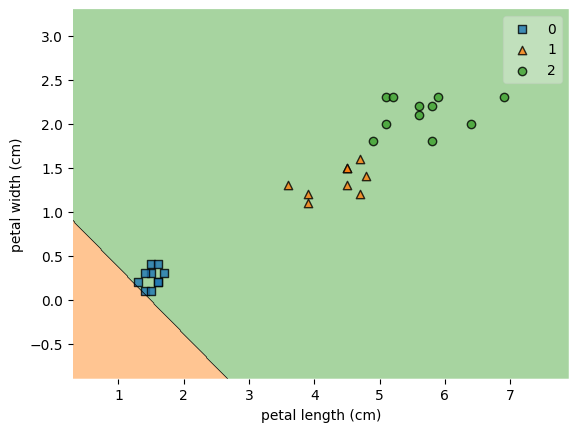

In [ ]:

decision_boundary_plot(X_test, y_test, X_train_scaled, y_train, model_Log_Reg_2, feature_indexes=[2,3])

Точность с примененной стандартизацией (масштабируем): 1.000 (100.0%)


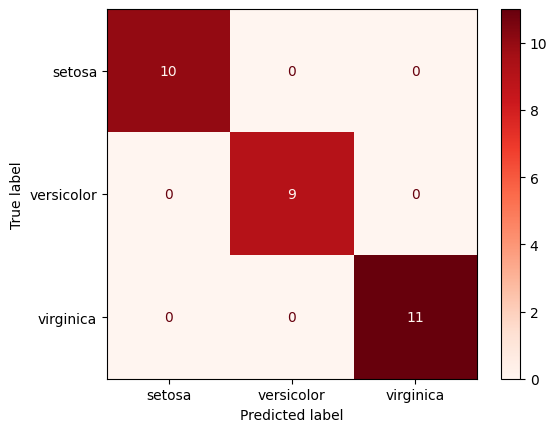

In [ ]:
model_Log_Reg_3 = LogisticRegression(C=100, max_iter=1000)
model_Log_Reg_3.fit(X_train_scaled, y_train)
pred_Log_Reg_3 = model_Log_Reg_3.predict(X_test_scaled)
accuracy_poly = accuracy_score(y_test, pred_Log_Reg_3)
print(f"Точность с примененной стандартизацией (масштабируем): {accuracy_poly:.3f} ({accuracy_poly*100:.1f}%)")

cm = confusion_matrix(y_test, pred_Log_Reg_3, labels=[0, 1, 2]
                      #labels=clf.classes_
                      )
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels= iris.target_names
                              #display_labels=clf.classes_
                              )
disp.plot(cmap=plt.cm.Reds)


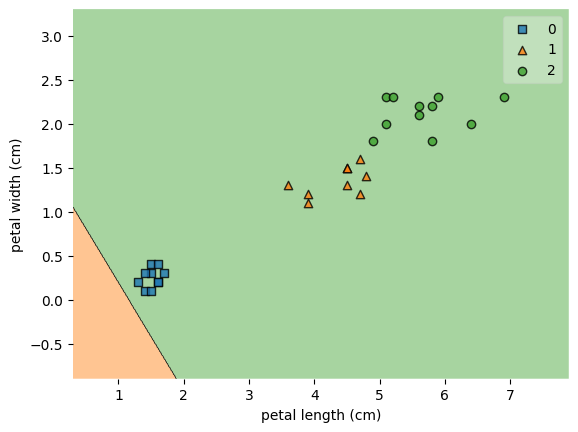

In [ ]:

decision_boundary_plot(X_test, y_test, X_train_scaled, y_train, model_Log_Reg_3, feature_indexes=[2,3])

### Рассмотрим алгоритм метод опорных векторов SVM

Здесь применена также масштабирование
Также используется GridSearch - подбор гиперпараметров для правильности результата точности

In [21]:
param_grid = {
    'C': [1, 10, 11, 12, 13, 14, 100, 1000],
    'gamma': [0.1, 1, 10, 28, 29, 30, 31]
}
metod_SVC = SVC(kernel='rbf')

grid = GridSearchCV(metod_SVC, param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая точность (cv):", grid.best_score_)

# предсказание на тесте
best_model = grid.best_estimator_

pred = best_model.predict(X_test_scaled)

# точность на тестовой выборке
accuracy = accuracy_score(y_test, pred)

print("Точность на тесте:", accuracy)

# plotDecisionBoundary(svcN, X, y)

NameError: name 'X_train_scaled' is not defined

### Рассмотрим алгоритм Случайный лес
- создает множество слабых деревьев (неуглубленные - решающий пень) независимых друг от друга
- использует бэггинг и подпространства
- низкий low bias (смещение) и высокий high variance (разброс)
- нет нужды использовать нормализацию

In [23]:

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5, None]
}
model_RF = RandomForestClassifier(random_state=42)

grid = GridSearchCV(model_RF, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая точность (cv):", grid.best_score_)

# предсказание на тесте
best_model = grid.best_estimator_

pred_RF = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred_RF)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_RF))
print(classification_report(y_test, pred_RF))

Лучшие параметры: {'max_depth': 3, 'n_estimators': 50}
Лучшая точность (cv): 0.95
Mean absolute error: 0.0
Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Алгоритма Градиентного спуска
- создает множество последовательных сильных деревьев (углубленных)
- использует градиент функции потерь ->  'направление' ошибки ансамбля
- высокий low bias (смещения) и низкий high variance (разброс)
- нет нужды использовать нормализацию

In [24]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [2, 3, 4]
}
model_GB = GradientBoostingClassifier(random_state=42)

grid = GridSearchCV(model_GB, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая точность (cv):", grid.best_score_)

# предсказание на тесте
best_model = grid.best_estimator_

pred_GB = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred_GB)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred_GB))
print(classification_report(y_test, pred_GB))

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}
Лучшая точность (cv): 0.95
Mean absolute error: 0.0
Gradient Boosting Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

